Zadatak: Predviđanje cijene kuće
Dan ti je skup podataka s ovim značajkama:


sqft — kvadratura (m²)~

rooms — broj soba

age — starost zgrade (godine)

price — cijena u tisućama € (ovo je y)

Tvoji zadaci:

Ispiši prvih 5 redaka i osnovne info o skupu

Razdvoji na X i y, zatim na train/test (80:20)

Natrenira LinearRegression model

Ispiši RMSE, MAE i R²

Ispiši koji feature najviše utječe na cijenu

Nacrtaj stvarne vs predviđene cijene (zelena = stvarne, plava isprekidana = predviđanje)

Mean Squared Error: 6713.99
R² Score: -0.05
Mean Absolute Error: 70.02


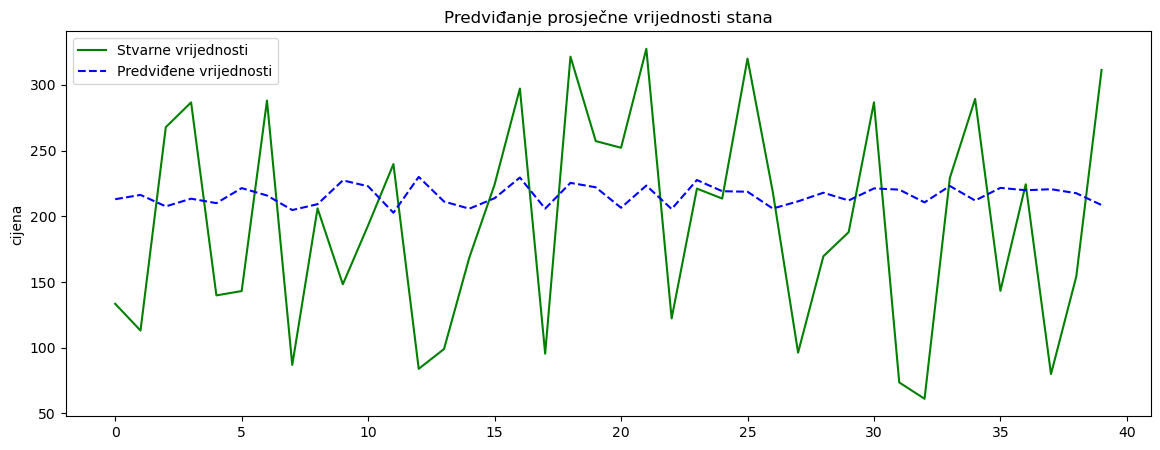

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Generiramo podatke (zamisli da je ovo CSV koji učitavaš)
np.random.seed(42)
n = 200
data = pd.DataFrame({
    'sqft':  np.random.randint(40, 200, n),
    'rooms': np.random.randint(1, 6, n),
    'age':   np.random.randint(1, 50, n),
    'price': np.random.randint(40, 200, n) * 1.8 + np.random.randn(n) * 20
})
#prvih 5 redova
data.head()

#razdvajanje na X i y i na train i test
X=data[['sqft', 'rooms', 'age']]
y=data['price']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
LR=LinearRegression()
LR.fit(X_train,y_train)
y_pred=LR.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')

pd.Series(LR.coef_, index=X.columns)
plt.figure(figsize=(14,5))
plt.plot(range(len(y_test)),y_test, color='green', label='Stvarne vrijednosti')
plt.plot(range(len(y_pred)),y_pred, color='blue', label='Predviđene vrijednosti', linestyle='--')
plt.title('Predviđanje prosječne vrijednosti stana')
plt.ylabel('cijena')
plt.legend()
plt.show()
